# 01 Evaluation Stability: Whole-Dataset CV vs Repeated Held-Out Splits

**Purpose:** establish a reliable evaluation protocol before comparing feature representations or model structures.

This notebook uses the **same all-in feature matrix** and the **same fixed Random Forest pipeline** under two evaluation settings:

1. **Whole-dataset repeated 5-fold CV**
   - Uses the full modelling dataset.
   - Runs shuffled 5-fold CV for 10 CV seeds (`0–9`).
   - Averages the five validation folds within each run.
   - Provides a conventional internal-CV reference.

2. **Repeated held-out evaluation**
   - Uses one random 80/20 train/test split for each of 10 split seeds (`0–9`).
   - Fits on the training partition and evaluates once on the untouched test partition.
   - Quantifies how strongly a single held-out score depends on the random split.

The whole-dataset CV results in this notebook are used only as an **evaluation-stability diagnostic**. Subsequent feature-set and model comparisons use paired repeated held-out splits and report mean ± standard deviation.

This notebook intentionally excludes feature selection, cleaning/noise-filter experiments, two-stage PCE modelling, source-aware splitting, permutation importance, and hyperparameter tuning.

In [1]:
# ============================================================
# 0. Imports and global settings
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, train_test_split, cross_validate
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# ----------------------------
# Experiment settings
# ----------------------------
# Ten seeds are used for both protocols.
WHOLE_CV_SEEDS = list(range(10))
HOLDOUT_SEEDS = list(range(10))

CV_SPLITS = 5
TEST_SIZE = 0.20

# RF settings: keep fixed so evaluation variability is not mixed with model-randomness variability.
N_ESTIMATORS = 200
MIN_SAMPLES_LEAF = 1
RF_RANDOM_STATE = 42
N_JOBS_RF = -1

PCE_TARGET = "jv.default_PCE"
JV_TARGETS = ["jv.default_Jsc", "jv.default_Voc", "jv.default_FF"]
TARGETS_TO_RUN = JV_TARGETS + [PCE_TARGET]

OUTPUT_DIR = Path("allin_wholecv_vs_holdout_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Settings")
print("-" * 60)
print("WHOLE_CV_SEEDS:", WHOLE_CV_SEEDS)
print("HOLDOUT_SEEDS:", HOLDOUT_SEEDS)
print("CV_SPLITS:", CV_SPLITS)
print("TEST_SIZE:", TEST_SIZE)
print("N_ESTIMATORS:", N_ESTIMATORS)
print("MIN_SAMPLES_LEAF:", MIN_SAMPLES_LEAF)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())


Settings
------------------------------------------------------------
WHOLE_CV_SEEDS: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
HOLDOUT_SEEDS: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
CV_SPLITS: 5
TEST_SIZE: 0.2
N_ESTIMATORS: 200
MIN_SAMPLES_LEAF: 1
OUTPUT_DIR: /Users/rosylu/Desktop/Project/allin_wholecv_vs_holdout_outputs


## 1. Load the fixed preprocessed dataset

This notebook starts from `df_base.csv`, produced by the preprocessing notebook. It does not repeat cleaning or preprocessing decisions.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_PATH = Path("df_base.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "df_base.csv not found. Please place df_base.csv in the same folder as this notebook."
    )

df_base = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Loaded fixed dataset: {DATA_PATH.resolve()}")
print("df_base shape:", df_base.shape)
print("First 10 columns:", df_base.columns[:10].tolist())

Loaded fixed dataset: /Users/rosylu/Desktop/Project/df_base.csv
df_base shape: (3953, 411)
First 10 columns: ['m_def', 'ref.internal_sample_id', 'ref.ID', 'ref.ID_temp', 'ref.name_of_person_entering_the_data', 'ref.data_entered_by_author', 'ref.DOI_number', 'ref.lead_author', 'ref.publication_date', 'ref.journal']


## 2. Build one controlled all-in modelling matrix

To isolate evaluation variability, all four targets use the same rows and the same frozen **207-feature all-in input set**:

- retain every eligible non-leakage raw descriptor with less than 50% missingness, including non-leakage stability/outdoor fields and `Unknown`-like categorical values;
- replace five duplicated raw thickness/band-gap representations with their cleaned versions;
- add three layer-count helpers and two Level-3 engineered thickness features;
- retain rows with valid Jsc, Voc, FF, and PCE targets.

This feature definition is fixed once and is not target-specific or selected separately for any target.


In [3]:
# ============================================================
# 2. Build canonical all-in X and target table Y
# ============================================================

# Frozen canonical all-in feature set:
# - all eligible non-leakage raw descriptors with <50% missingness;
# - five duplicated raw thickness/band-gap fields replaced by clean versions;
# - three layer-count helpers;
# - two Level-3 engineered thickness features.
ALL_IN_FEATURES = [
    "etl.additives_compounds",
    "encapsulation.edge_sealing_materials",
    "perovskite_bandgap_clean",
    "perovskite.band_gap_graded",
    "perovskite.composition_a_ions",
    "perovskite.composition_a_ions_coefficients",
    "perovskite.composition_b_ions",
    "perovskite.composition_b_ions_coefficients",
    "perovskite.composition_c_ions",
    "perovskite.composition_c_ions_coefficients",
    "perovskite.composition_inorganic",
    "perovskite.composition_leadfree",
    "perovskite.composition_long_form",
    "perovskite.composition_perovskite_ABC3_structure",
    "perovskite.composition_perovskite_inspired_structure",
    "perovskite.composition_short_form",
    "perovskite.dimension_0D",
    "perovskite.dimension_2D",
    "perovskite.dimension_2D3D_mixture",
    "perovskite.dimension_3D",
    "perovskite.dimension_3D_with_2D_capping_layer",
    "perovskite.dimension_list_of_layers",
    "perovskite.ions",
    "perovskite.single_crystal",
    "PVK_thickness_clean",
    "add.lay_back",
    "add.lay_front",
    "add.lay_back_stack_sequence",
    "add.lay_front_stack_sequence",
    "backcontact.stack_sequence",
    "BC_thickness_clean",
    "cell.architecture",
    "cell.area_measured",
    "cell.flexible",
    "cell.number_of_cells_per_substrate",
    "cell.semitransparent",
    "cell.semitransparent_wavelength_range",
    "cell.stack_sequence",
    "etl.stack_sequence",
    "ETL_thickness_clean",
    "encapsulation.Encapsulation",
    "encapsulation.stack_sequence",
    "htl.stack_sequence",
    "HTL_thickness_clean",
    "module.Module",
    "module.number_of_cells_in_module",
    "substrate.stack_sequence",
    "perovskite_deposition.aggregation_state_of_reactants",
    "perovskite_deposition.number_of_deposition_steps",
    "perovskite_deposition.procedure",
    "perovskite_deposition.substrate_temperature",
    "perovskite_deposition.synthesis_atmosphere",
    "add.lay_back_deposition_aggregation_state_of_reactants",
    "add.lay_back_deposition_procedure",
    "add.lay_back_deposition_reaction_solutions_age",
    "add.lay_back_deposition_reaction_solutions_compounds_purity",
    "add.lay_back_deposition_reaction_solutions_compounds_supplier",
    "add.lay_back_deposition_reaction_solutions_temperature",
    "add.lay_back_deposition_reaction_solutions_volumes",
    "add.lay_back_deposition_solvents",
    "add.lay_back_deposition_solvents_purity",
    "add.lay_back_deposition_solvents_supplier",
    "add.lay_back_deposition_substrate_temperature",
    "add.lay_back_deposition_synthesis_atmosphere",
    "add.lay_back_deposition_thermal_annealing_atmosphere",
    "add.lay_back_deposition_thermal_annealing_temperature",
    "add.lay_back_deposition_thermal_annealing_time",
    "add.lay_front_deposition_aggregation_state_of_reactants",
    "add.lay_front_deposition_procedure",
    "add.lay_front_deposition_reaction_solutions_age",
    "add.lay_front_deposition_reaction_solutions_compounds_purity",
    "add.lay_front_deposition_reaction_solutions_compounds_supplier",
    "add.lay_front_deposition_reaction_solutions_temperature",
    "add.lay_front_deposition_reaction_solutions_volumes",
    "add.lay_front_deposition_solvents",
    "add.lay_front_deposition_solvents_purity",
    "add.lay_front_deposition_solvents_supplier",
    "add.lay_front_deposition_substrate_temperature",
    "add.lay_front_deposition_synthesis_atmosphere",
    "add.lay_front_deposition_thermal_annealing_atmosphere",
    "add.lay_front_deposition_thermal_annealing_temperature",
    "add.lay_front_deposition_thermal_annealing_time",
    "backcontact.deposition_aggregation_state_of_reactants",
    "backcontact.deposition_procedure",
    "backcontact.deposition_substrate_temperature",
    "backcontact.deposition_synthesis_atmosphere",
    "backcontact.deposition_reaction_solutions_age",
    "backcontact.deposition_reaction_solutions_compounds_purity",
    "backcontact.deposition_reaction_solutions_compounds_supplier",
    "backcontact.deposition_reaction_solutions_temperature",
    "backcontact.deposition_reaction_solutions_volumes",
    "backcontact.deposition_solvents",
    "backcontact.deposition_solvents_purity",
    "backcontact.deposition_solvents_supplier",
    "backcontact.deposition_thermal_annealing_atmosphere",
    "backcontact.deposition_thermal_annealing_temperature",
    "backcontact.deposition_thermal_annealing_time",
    "etl.deposition_aggregation_state_of_reactants",
    "etl.deposition_procedure",
    "etl.deposition_substrate_temperature",
    "etl.deposition_synthesis_atmosphere",
    "etl.deposition_reaction_solutions_age",
    "etl.deposition_reaction_solutions_compounds_purity",
    "etl.deposition_reaction_solutions_compounds_supplier",
    "etl.deposition_reaction_solutions_temperature",
    "etl.deposition_reaction_solutions_volumes",
    "etl.deposition_solvents",
    "etl.deposition_solvents_purity",
    "etl.deposition_solvents_supplier",
    "etl.deposition_thermal_annealing_atmosphere",
    "etl.deposition_thermal_annealing_temperature",
    "etl.deposition_thermal_annealing_time",
    "encapsulation.atmosphere_for_encapsulation",
    "htl.deposition_aggregation_state_of_reactants",
    "htl.deposition_procedure",
    "htl.deposition_substrate_temperature",
    "htl.deposition_synthesis_atmosphere",
    "htl.deposition_reaction_solutions_age",
    "htl.deposition_reaction_solutions_compounds_purity",
    "htl.deposition_reaction_solutions_compounds_supplier",
    "htl.deposition_reaction_solutions_temperature",
    "htl.deposition_reaction_solutions_volumes",
    "htl.deposition_solvents",
    "htl.deposition_solvents_purity",
    "htl.deposition_solvents_supplier",
    "htl.deposition_thermal_annealing_atmosphere",
    "htl.deposition_thermal_annealing_temperature",
    "htl.deposition_thermal_annealing_time",
    "add.lay_back_storage_atmosphere",
    "add.lay_back_storage_time_until_next_deposition_step",
    "add.lay_front_storage_atmosphere",
    "add.lay_front_storage_time_until_next_deposition_step",
    "backcontact.storage_atmosphere",
    "backcontact.storage_time_until_next_deposition_step",
    "etl.storage_atmosphere",
    "htl.storage_atmosphere",
    "htl.storage_time_until_next_deposition_step",
    "perovskite.storage_atmosphere",
    "perovskite.storage_time_until_next_deposition_step",
    "perovskite_deposition.reaction_solutions_age",
    "perovskite_deposition.reaction_solutions_compounds_purity",
    "perovskite_deposition.reaction_solutions_compounds_supplier",
    "perovskite_deposition.reaction_solutions_temperature",
    "perovskite_deposition.reaction_solutions_volumes",
    "perovskite_deposition.solvents",
    "perovskite_deposition.solvents_mixing_ratios",
    "perovskite_deposition.solvents_purity",
    "perovskite_deposition.solvents_supplier",
    "perovskite_deposition.quenching_induced_crystallisation",
    "perovskite_deposition.quenching_media",
    "perovskite_deposition.quenching_media_volume",
    "perovskite_deposition.solvent_annealing",
    "perovskite_deposition.solvent_annealing_solvent_atmosphere",
    "perovskite_deposition.solvent_annealing_temperature",
    "perovskite_deposition.solvent_annealing_time",
    "substrate.deposition_procedure",
    "perovskite_deposition.thermal_annealing_atmosphere",
    "perovskite_deposition.thermal_annealing_temperature",
    "perovskite_deposition.thermal_annealing_time",
    "perovskite.band_gap_estimation_basis",
    "jv.certified_values",
    "eqe.measured",
    "jv.average_over_n_number_of_cells",
    "jv.light_intensity",
    "jv.light_masked_cell",
    "jv.light_spectra",
    "jv.light_wavelength_range",
    "jv.measured",
    "jv.storage_age_of_cell",
    "jv.storage_atmosphere",
    "jv.test_atmosphere",
    "module.JV_data_recalculated_per_cell",
    "outdoor.average_over_n_number_of_cells",
    "outdoor.detaild_weather_data_available",
    "outdoor.installation_number_of_solar_tracking_axis",
    "outdoor.irradiance_measured",
    "outdoor.location_coordinates",
    "outdoor.periodic_JV_measurements",
    "outdoor.potential_bias_range",
    "outdoor.spectral_data_available",
    "outdoor.temperature_range",
    "outdoor.tested",
    "outdoor.time_end",
    "outdoor.time_start",
    "jv.default_FF_scan_direction",
    "jv.default_Jsc_scan_direction",
    "jv.default_PCE_scan_direction",
    "jv.default_Voc_scan_direction",
    "stabilised.performance_measured",
    "stability.atmosphere",
    "stability.average_over_n_number_of_cells",
    "stability.flexible_cell_number_of_bending_cycles",
    "stability.light_UV_filter",
    "stability.light_cycling_times",
    "stability.light_wavelength_range",
    "stability.measured",
    "stability.periodic_JV_measurements",
    "stability.periodic_JV_measurements_time_between_jv",
    "stability.potential_bias_range",
    "stability.relative_humidity_range",
    "stability.temperature_cycling_times",
    "stability.temperature_range",
    "ETL_n_layers",
    "HTL_n_layers",
    "BC_n_layers",
    "Absorber_to_ETL_ratio",
    "ff_PVK_fraction_of_total_stack"
]

RAW_DUPLICATE_FEATURES = [
    "perovskite.band_gap",
    "perovskite.thickness",
    "etl.thickness",
    "htl.thickness_list",
    "backcontact.thickness_list",
]

LEVEL3_FEATURES = [
    "Absorber_to_ETL_ratio",
    "ff_PVK_fraction_of_total_stack",
]


def safe_divide(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    return (numerator / denominator).replace([np.inf, -np.inf], np.nan)


# Create only the two agreed Level-3 features.
pvk = pd.to_numeric(df_base["PVK_thickness_clean"], errors="coerce")
etl = pd.to_numeric(df_base["ETL_thickness_clean"], errors="coerce")
htl = pd.to_numeric(df_base["HTL_thickness_clean"], errors="coerce")
bc = pd.to_numeric(df_base["BC_thickness_clean"], errors="coerce")

df_base["Absorber_to_ETL_ratio"] = safe_divide(pvk, etl)
df_base["ff_PVK_fraction_of_total_stack"] = safe_divide(
    pvk,
    pvk + etl + htl + bc,
)

NEEDED_TARGETS = JV_TARGETS + [PCE_TARGET]

missing_targets = [c for c in NEEDED_TARGETS if c not in df_base.columns]
if missing_targets:
    raise ValueError("Missing target columns in df_base: " + ", ".join(missing_targets))

missing_features = [c for c in ALL_IN_FEATURES if c not in df_base.columns]
if missing_features:
    raise ValueError(
        "Missing canonical all-in features in df_base: "
        + ", ".join(missing_features)
    )

assert len(ALL_IN_FEATURES) == 207
assert len(ALL_IN_FEATURES) == len(set(ALL_IN_FEATURES))
assert set(RAW_DUPLICATE_FEATURES).isdisjoint(ALL_IN_FEATURES)
assert set(LEVEL3_FEATURES).issubset(ALL_IN_FEATURES)

Y_all = df_base[NEEDED_TARGETS].copy()
for col in NEEDED_TARGETS:
    Y_all[col] = pd.to_numeric(Y_all[col], errors="coerce")

mask = Y_all.notna().all(axis=1)
Y = Y_all.loc[mask].copy()

X_all = df_base.loc[mask, ALL_IN_FEATURES].copy()
X_all = X_all.replace({pd.NA: np.nan})

print("Samples used:", len(X_all))
print("Canonical all-in features:", X_all.shape[1])
print("Targets:", Y.shape)
print("Numeric all-in features:", len(X_all.select_dtypes(include=np.number).columns))
print("Categorical all-in features:", X_all.shape[1] - len(X_all.select_dtypes(include=np.number).columns))
print("Level-3 features included:", LEVEL3_FEATURES)
print("First 20 all-in features:")
print(X_all.columns[:20].tolist())

pd.Series(X_all.columns, name="allin_feature").to_csv(
    OUTPUT_DIR / "allin_feature_list.csv",
    index=False,
)


Samples used: 3953
Canonical all-in features: 207
Targets: (3953, 4)
Numeric all-in features: 20
Categorical all-in features: 187
Level-3 features included: ['Absorber_to_ETL_ratio', 'ff_PVK_fraction_of_total_stack']
First 20 all-in features:
['etl.additives_compounds', 'encapsulation.edge_sealing_materials', 'perovskite_bandgap_clean', 'perovskite.band_gap_graded', 'perovskite.composition_a_ions', 'perovskite.composition_a_ions_coefficients', 'perovskite.composition_b_ions', 'perovskite.composition_b_ions_coefficients', 'perovskite.composition_c_ions', 'perovskite.composition_c_ions_coefficients', 'perovskite.composition_inorganic', 'perovskite.composition_leadfree', 'perovskite.composition_long_form', 'perovskite.composition_perovskite_ABC3_structure', 'perovskite.composition_perovskite_inspired_structure', 'perovskite.composition_short_form', 'perovskite.dimension_0D', 'perovskite.dimension_2D', 'perovskite.dimension_2D3D_mixture', 'perovskite.dimension_3D']


## 3. Fixed preprocessing and Random Forest model

Numeric imputation, categorical imputation, and one-hot encoding are fitted inside each CV fold or held-out training partition. Model randomness is fixed at 42 so that variation reflects only the data partition.

In [4]:
# ============================================================
# 3. Modelling helpers
# ============================================================


def make_rf_pipeline(X, rf_random_state=RF_RANDOM_STATE):
    """Create the same all-in preprocessing + RF pipeline for any raw feature matrix X."""
    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("to_str", FunctionTransformer(lambda x: x.astype(str), validate=False)),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ])

    rf = RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        random_state=rf_random_state,
        n_jobs=N_JOBS_RF,
    )

    return Pipeline([
        ("prep", preprocessor),
        ("rf", rf),
    ])


def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def safe_target_name(target):
    return target.replace("jv.default_", "")


def summarise_range(s):
    return s.max() - s.min()


## 4. Experiment A — Whole-dataset repeated 5-fold CV

For each of 10 CV seeds, shuffled 5-fold CV is run on the complete modelling matrix for Jsc, Voc, FF, and PCE. The five validation scores are averaged within each run.

These scores provide an internal-CV reference; they are not used as the final predictive comparison reported for later experiments.

In [5]:
# ============================================================
# 4. Whole-dataset repeated 5-fold CV
# ============================================================

whole_cv_rows = []
whole_cv_partial_path = OUTPUT_DIR / "whole_dataset_cv_results_PARTIAL.csv"
whole_cv_final_path = OUTPUT_DIR / "whole_dataset_cv_results.csv"

print("Starting Experiment A: whole-dataset repeated CV")
print(f"  n CV seeds: {len(WHOLE_CV_SEEDS)}")
print(f"  CV splits: {CV_SPLITS}")
print(f"  targets: {TARGETS_TO_RUN}")
print(f"  Partial output: {whole_cv_partial_path}")

for cv_seed in WHOLE_CV_SEEDS:
    print("\n" + "=" * 90)
    print(f"Whole-dataset CV seed {cv_seed}")
    print("=" * 90)

    cv = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=cv_seed)

    for target in TARGETS_TO_RUN:
        target_short = safe_target_name(target)
        y = Y[target]
        model = make_rf_pipeline(X_all, rf_random_state=RF_RANDOM_STATE)

        cv_out = cross_validate(
            model,
            X_all,
            y,
            cv=cv,
            scoring={
                "r2": "r2",
                "rmse": "neg_root_mean_squared_error",
            },
            n_jobs=1,
            return_train_score=False,
        )

        fold_r2 = cv_out["test_r2"]
        fold_rmse = -cv_out["test_rmse"]

        row = {
            "evaluation": "whole_dataset_cv",
            "cv_seed": cv_seed,
            "target": target,
            "target_short": target_short,
            "n_samples": len(X_all),
            "n_raw_features": X_all.shape[1],
            "cv_splits": CV_SPLITS,
            "n_estimators": N_ESTIMATORS,
            "min_samples_leaf": MIN_SAMPLES_LEAF,
            "CV_R2_mean": fold_r2.mean(),
            "CV_R2_std_within_run": fold_r2.std(ddof=1),
            "CV_R2_min_fold": fold_r2.min(),
            "CV_R2_max_fold": fold_r2.max(),
            "CV_RMSE_mean": fold_rmse.mean(),
            "CV_RMSE_std_within_run": fold_rmse.std(ddof=1),
            "CV_RMSE_min_fold": fold_rmse.min(),
            "CV_RMSE_max_fold": fold_rmse.max(),
        }
        whole_cv_rows.append(row)
        pd.DataFrame(whole_cv_rows).to_csv(whole_cv_partial_path, index=False)

        print(
            f"  {target_short:<4} | CV R2={row['CV_R2_mean']:.4f} ± {row['CV_R2_std_within_run']:.4f} "
            f"| CV RMSE={row['CV_RMSE_mean']:.4f} ± {row['CV_RMSE_std_within_run']:.4f}"
        )

whole_cv_df = pd.DataFrame(whole_cv_rows)
whole_cv_df.to_csv(whole_cv_final_path, index=False)

print("\nExperiment A done.")
print("Saved:", whole_cv_final_path)
display(whole_cv_df.head())


Starting Experiment A: whole-dataset repeated CV
  n CV seeds: 10
  CV splits: 5
  targets: ['jv.default_Jsc', 'jv.default_Voc', 'jv.default_FF', 'jv.default_PCE']
  Partial output: allin_wholecv_vs_holdout_outputs/whole_dataset_cv_results_PARTIAL.csv

Whole-dataset CV seed 0
  Jsc  | CV R2=0.6526 ± 0.0524 | CV RMSE=2.7170 ± 0.0953
  Voc  | CV R2=0.6064 ± 0.0306 | CV RMSE=0.0901 ± 0.0065
  FF   | CV R2=0.4965 ± 0.0096 | CV RMSE=0.0736 ± 0.0023
  PCE  | CV R2=0.6678 ± 0.0150 | CV RMSE=2.7285 ± 0.0468

Whole-dataset CV seed 1
  Jsc  | CV R2=0.6623 ± 0.0449 | CV RMSE=2.6934 ± 0.2442
  Voc  | CV R2=0.6346 ± 0.0706 | CV RMSE=0.0867 ± 0.0120
  FF   | CV R2=0.4855 ± 0.0508 | CV RMSE=0.0744 ± 0.0051
  PCE  | CV R2=0.6643 ± 0.0275 | CV RMSE=2.7492 ± 0.1656

Whole-dataset CV seed 2
  Jsc  | CV R2=0.6600 ± 0.0489 | CV RMSE=2.6942 ± 0.1394
  Voc  | CV R2=0.6333 ± 0.0609 | CV RMSE=0.0867 ± 0.0099
  FF   | CV R2=0.4799 ± 0.0430 | CV RMSE=0.0748 ± 0.0028
  PCE  | CV R2=0.6606 ± 0.0327 | CV RMSE=2.758

,evaluation,cv_seed,target,target_short,n_samples,n_raw_features,cv_splits,n_estimators,min_samples_leaf,CV_R2_mean,CV_R2_std_within_run,CV_R2_min_fold,CV_R2_max_fold,CV_RMSE_mean,CV_RMSE_std_within_run,CV_RMSE_min_fold,CV_RMSE_max_fold
0,whole_dataset_cv,0,jv.default_Jsc,Jsc,3953,207,5,200,1,0.652631,0.052423,0.596426,0.717682,2.716967,0.095272,2.602477,2.841014
1,whole_dataset_cv,0,jv.default_Voc,Voc,3953,207,5,200,1,0.606361,0.030583,0.585548,0.659482,0.090084,0.006484,0.085302,0.101181
2,whole_dataset_cv,0,jv.default_FF,FF,3953,207,5,200,1,0.496464,0.009576,0.486691,0.508247,0.073614,0.002271,0.070678,0.076797
3,whole_dataset_cv,0,jv.default_PCE,PCE,3953,207,5,200,1,0.667775,0.015028,0.647537,0.682396,2.728530,0.046815,2.652628,2.780616
4,whole_dataset_cv,1,jv.default_Jsc,Jsc,3953,207,5,200,1,0.662289,0.044942,0.607000,0.729031,2.693403,0.244189,2.364020,3.002852


## 5. Experiment B — Repeated 80/20 held-out evaluation

The same all-in matrix and fixed RF pipeline are evaluated across 10 random train/test splits. Only the partition seed changes.

This cell does not run train-only CV or hyperparameter tuning. Its purpose is to measure the variability of a single train-once/test-once estimate.

In [6]:
# ============================================================
# 5. Repeated held-out train/test split
# ============================================================

holdout_rows = []
holdout_partial_path = OUTPUT_DIR / "repeated_heldout_results_PARTIAL.csv"
holdout_final_path = OUTPUT_DIR / "repeated_heldout_results.csv"

print("Starting Experiment B: repeated held-out train/test split")
print(f"  n split seeds: {len(HOLDOUT_SEEDS)}")
print(f"  test size: {TEST_SIZE}")
print(f"  targets: {TARGETS_TO_RUN}")
print(f"  Partial output: {holdout_partial_path}")

for split_seed in HOLDOUT_SEEDS:
    print("\n" + "=" * 90)
    print(f"Held-out split seed {split_seed}")
    print("=" * 90)

    train_idx, test_idx = train_test_split(
        np.arange(len(X_all)),
        test_size=TEST_SIZE,
        random_state=split_seed,
        shuffle=True,
    )

    X_train = X_all.iloc[train_idx].copy()
    X_test = X_all.iloc[test_idx].copy()
    Y_train = Y.iloc[train_idx].copy()
    Y_test = Y.iloc[test_idx].copy()

    for target in TARGETS_TO_RUN:
        target_short = safe_target_name(target)
        y_train = Y_train[target]
        y_test = Y_test[target]

        model = make_rf_pipeline(X_train, rf_random_state=RF_RANDOM_STATE)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        test_rmse = rmse_score(y_test, y_pred)
        test_r2 = r2_score(y_test, y_pred)

        row = {
            "evaluation": "repeated_heldout",
            "split_seed": split_seed,
            "target": target,
            "target_short": target_short,
            "n_train": len(X_train),
            "n_test": len(X_test),
            "n_raw_features": X_all.shape[1],
            "n_estimators": N_ESTIMATORS,
            "min_samples_leaf": MIN_SAMPLES_LEAF,
            "Test_R2": test_r2,
            "Test_RMSE": test_rmse,
            "train_target_mean": y_train.mean(),
            "train_target_std": y_train.std(ddof=1),
            "test_target_mean": y_test.mean(),
            "test_target_std": y_test.std(ddof=1),
        }
        holdout_rows.append(row)
        pd.DataFrame(holdout_rows).to_csv(holdout_partial_path, index=False)

        print(
            f"  {target_short:<4} | TEST R2={test_r2:.4f} | TEST RMSE={test_rmse:.4f} "
            f"| test mean/std={y_test.mean():.4f}/{y_test.std(ddof=1):.4f}"
        )

    seed_df = pd.DataFrame([r for r in holdout_rows if r["split_seed"] == split_seed])
    print("\n  Finished held-out seed summary:")
    display(seed_df[["target_short", "Test_R2", "Test_RMSE", "test_target_mean", "test_target_std"]])

holdout_df = pd.DataFrame(holdout_rows)
holdout_df.to_csv(holdout_final_path, index=False)

print("\nExperiment B done.")
print("Saved:", holdout_final_path)
display(holdout_df.head())


Starting Experiment B: repeated held-out train/test split
  n split seeds: 10
  test size: 0.2
  targets: ['jv.default_Jsc', 'jv.default_Voc', 'jv.default_FF', 'jv.default_PCE']
  Partial output: allin_wholecv_vs_holdout_outputs/repeated_heldout_results_PARTIAL.csv

Held-out split seed 0
  Jsc  | TEST R2=0.6686 | TEST RMSE=2.6648 | test mean/std=19.0485/4.6320
  Voc  | TEST R2=0.5827 | TEST RMSE=0.0893 | test mean/std=0.9874/0.1384
  FF   | TEST R2=0.5089 | TEST RMSE=0.0726 | test mean/std=0.6799/0.1037
  PCE  | TEST R2=0.6833 | TEST RMSE=2.7375 | test mean/std=13.3470/4.8676

  Finished held-out seed summary:


,target_short,Test_R2,Test_RMSE,test_target_mean,test_target_std
0,Jsc,0.668598,2.664832,19.048496,4.631983
1,Voc,0.582719,0.089345,0.987410,0.138398
2,FF,0.508901,0.072608,0.679898,0.103674
3,PCE,0.683329,2.737456,13.347019,4.867632



Held-out split seed 1
  Jsc  | TEST R2=0.6068 | TEST RMSE=3.0037 | test mean/std=18.7918/4.7931
  Voc  | TEST R2=0.5915 | TEST RMSE=0.0981 | test mean/std=0.9719/0.1535
  FF   | TEST R2=0.4158 | TEST RMSE=0.0799 | test mean/std=0.6712/0.1046
  PCE  | TEST R2=0.6397 | TEST RMSE=2.8832 | test mean/std=12.9057/4.8061

  Finished held-out seed summary:


,target_short,Test_R2,Test_RMSE,test_target_mean,test_target_std
0,Jsc,0.606770,3.003733,18.791846,4.793056
1,Voc,0.591520,0.098074,0.971942,0.153547
2,FF,0.415787,0.079932,0.671225,0.104643
3,PCE,0.639651,2.883217,12.905651,4.806075



Held-out split seed 2
  Jsc  | TEST R2=0.6479 | TEST RMSE=2.8338 | test mean/std=18.7019/4.7786
  Voc  | TEST R2=0.5609 | TEST RMSE=0.1034 | test mean/std=0.9753/0.1561
  FF   | TEST R2=0.4844 | TEST RMSE=0.0762 | test mean/std=0.6670/0.1062
  PCE  | TEST R2=0.6582 | TEST RMSE=2.8231 | test mean/std=12.8202/4.8319

  Finished held-out seed summary:


...

,target_short,Test_R2,Test_RMSE,test_target_mean,test_target_std
0,Jsc,0.713067,2.443757,18.925032,4.565014
1,Voc,0.668614,0.079308,0.987190,0.137855
2,FF,0.491207,0.070467,0.678309,0.098853
3,PCE,0.654858,2.708832,13.224742,4.613791



Held-out split seed 9
  Jsc  | TEST R2=0.6285 | TEST RMSE=2.8490 | test mean/std=18.6361/4.6776
  Voc  | TEST R2=0.7044 | TEST RMSE=0.0808 | test mean/std=0.9734/0.1487
  FF   | TEST R2=0.4982 | TEST RMSE=0.0757 | test mean/std=0.6666/0.1070
  PCE  | TEST R2=0.6834 | TEST RMSE=2.7438 | test mean/std=12.7075/4.8792

  Finished held-out seed summary:


,target_short,Test_R2,Test_RMSE,test_target_mean,test_target_std
0,Jsc,0.628549,2.849046,18.636102,4.677607
1,Voc,0.704388,0.080802,0.973385,0.148708
2,FF,0.498216,0.075724,0.666582,0.106967
3,PCE,0.683371,2.743793,12.707497,4.879222



Experiment B done.
Saved: allin_wholecv_vs_holdout_outputs/repeated_heldout_results.csv


,evaluation,split_seed,target,target_short,n_train,n_test,n_raw_features,n_estimators,min_samples_leaf,Test_R2,Test_RMSE,train_target_mean,train_target_std,test_target_mean,test_target_std
0,repeated_heldout,0,jv.default_Jsc,Jsc,3162,791,207,200,1,0.668598,2.664832,18.697251,4.640337,19.048496,4.631983
1,repeated_heldout,0,jv.default_Voc,Voc,3162,791,207,200,1,0.582719,0.089345,0.975651,0.145391,0.987410,0.138398
2,repeated_heldout,0,jv.default_FF,FF,3162,791,207,200,1,0.508901,0.072608,0.670020,0.103851,0.679898,0.103674
3,repeated_heldout,0,jv.default_PCE,PCE,3162,791,207,200,1,0.683329,2.737456,12.831184,4.711143,13.347019,4.867632
4,repeated_heldout,1,jv.default_Jsc,Jsc,3162,791,207,200,1,0.606770,3.003733,18.761454,4.601938,18.791846,4.793056


## 6. Summarise both evaluation protocols

The report-ready table compares:

- the distribution of mean scores from 10 whole-dataset CV runs; and
- the distribution of 10 held-out test scores.

The across-run standard deviations and ranges quantify partition sensitivity. The qualitative sensitivity flag is descriptive, not a statistical significance test.

In [7]:
# ============================================================
# 6. Summary tables
# ============================================================

# If the long cells were interrupted, load partial files when final variables are not available.
if "whole_cv_df" not in globals() or len(whole_cv_df) == 0:
    if whole_cv_partial_path.exists():
        whole_cv_df = pd.read_csv(whole_cv_partial_path)
    else:
        raise RuntimeError("No whole CV results found.")

if "holdout_df" not in globals() or len(holdout_df) == 0:
    if holdout_partial_path.exists():
        holdout_df = pd.read_csv(holdout_partial_path)
    else:
        raise RuntimeError("No held-out results found.")

whole_cv_summary = (
    whole_cv_df
    .groupby(["target", "target_short"], as_index=False)
    .agg(
        n_cv_runs=("cv_seed", "nunique"),
        n_samples=("n_samples", "first"),
        n_raw_features=("n_raw_features", "first"),
        cv_splits=("cv_splits", "first"),
        Whole_CV_R2_mean=("CV_R2_mean", "mean"),
        Whole_CV_R2_std_across_runs=("CV_R2_mean", "std"),
        Whole_CV_R2_min_run=("CV_R2_mean", "min"),
        Whole_CV_R2_max_run=("CV_R2_mean", "max"),
        Whole_CV_R2_range_across_runs=("CV_R2_mean", summarise_range),
        Whole_CV_RMSE_mean=("CV_RMSE_mean", "mean"),
        Whole_CV_RMSE_std_across_runs=("CV_RMSE_mean", "std"),
    )
)

holdout_summary = (
    holdout_df
    .groupby(["target", "target_short"], as_index=False)
    .agg(
        n_holdout_splits=("split_seed", "nunique"),
        n_train=("n_train", "first"),
        n_test=("n_test", "first"),
        Heldout_Test_R2_mean=("Test_R2", "mean"),
        Heldout_Test_R2_std=("Test_R2", "std"),
        Heldout_Test_R2_min=("Test_R2", "min"),
        Heldout_Test_R2_max=("Test_R2", "max"),
        Heldout_Test_R2_range=("Test_R2", summarise_range),
        Heldout_Test_RMSE_mean=("Test_RMSE", "mean"),
        Heldout_Test_RMSE_std=("Test_RMSE", "std"),
        Heldout_Test_RMSE_min=("Test_RMSE", "min"),
        Heldout_Test_RMSE_max=("Test_RMSE", "max"),
    )
)

comparison_summary = whole_cv_summary.merge(
    holdout_summary,
    on=["target", "target_short"],
    how="inner",
)

comparison_summary["Heldout_minus_Whole_CV_mean_R2"] = (
    comparison_summary["Heldout_Test_R2_mean"] - comparison_summary["Whole_CV_R2_mean"]
)

comparison_summary["Heldout_range_minus_WholeCV_run_range_R2"] = (
    comparison_summary["Heldout_Test_R2_range"] - comparison_summary["Whole_CV_R2_range_across_runs"]
)

# Simple descriptive flag. This is not a statistical test; it is just for quick reading.
def split_sensitivity_flag(rng):
    if rng >= 0.10:
        return "high split sensitivity"
    if rng >= 0.05:
        return "moderate split sensitivity"
    return "low split sensitivity"

comparison_summary["Heldout_instability_flag"] = comparison_summary["Heldout_Test_R2_range"].apply(split_sensitivity_flag)

comparison_summary = comparison_summary.sort_values("target_short")

whole_cv_summary.to_csv(OUTPUT_DIR / "whole_dataset_cv_summary.csv", index=False)
holdout_summary.to_csv(OUTPUT_DIR / "repeated_heldout_summary.csv", index=False)
comparison_summary.to_csv(OUTPUT_DIR / "wholecv_vs_repeated_holdout_comparison_summary.csv", index=False)

print("Whole-dataset CV summary")
display(whole_cv_summary.sort_values("target_short"))

print("Repeated held-out summary")
display(holdout_summary.sort_values("target_short"))

print("Report-ready comparison summary")
display(comparison_summary)

print("Saved summary files in:", OUTPUT_DIR.resolve())


Whole-dataset CV summary


,target,target_short,n_cv_runs,n_samples,n_raw_features,cv_splits,Whole_CV_R2_mean,Whole_CV_R2_std_across_runs,Whole_CV_R2_min_run,Whole_CV_R2_max_run,Whole_CV_R2_range_across_runs,Whole_CV_RMSE_mean,Whole_CV_RMSE_std_across_runs
0,jv.default_FF,FF,10,3953,207,5,0.484369,0.007853,0.472743,0.496464,0.023721,0.074460,0.000551
1,jv.default_Jsc,Jsc,10,3953,207,5,0.657035,0.007772,0.644431,0.669690,0.025258,2.706596,0.025536
2,jv.default_PCE,PCE,10,3953,207,5,0.663190,0.004245,0.654290,0.668264,0.013974,2.749405,0.017025
3,jv.default_Voc,Voc,10,3953,207,5,0.626914,0.015797,0.594715,0.643523,0.048808,0.087344,0.001720


Repeated held-out summary


,target,target_short,n_holdout_splits,n_train,n_test,Heldout_Test_R2_mean,Heldout_Test_R2_std,Heldout_Test_R2_min,Heldout_Test_R2_max,Heldout_Test_R2_range,Heldout_Test_RMSE_mean,Heldout_Test_RMSE_std,Heldout_Test_RMSE_min,Heldout_Test_RMSE_max
0,jv.default_FF,FF,10,3162,791,0.484240,0.027487,0.415787,0.515888,0.100101,0.074670,0.002585,0.070467,0.079932
1,jv.default_Jsc,Jsc,10,3162,791,0.647514,0.033247,0.606770,0.713067,0.106297,2.737779,0.162927,2.443757,3.003733
2,jv.default_PCE,PCE,10,3162,791,0.663024,0.019866,0.639651,0.696653,0.057001,2.757619,0.066545,2.660298,2.883217
3,jv.default_Voc,Voc,10,3162,791,0.621966,0.061646,0.538172,0.724866,0.186693,0.090859,0.008438,0.079308,0.103354


Report-ready comparison summary


,target,target_short,n_cv_runs,n_samples,n_raw_features,cv_splits,Whole_CV_R2_mean,Whole_CV_R2_std_across_runs,Whole_CV_R2_min_run,Whole_CV_R2_max_run,...,Heldout_Test_R2_min,Heldout_Test_R2_max,Heldout_Test_R2_range,Heldout_Test_RMSE_mean,Heldout_Test_RMSE_std,Heldout_Test_RMSE_min,Heldout_Test_RMSE_max,Heldout_minus_Whole_CV_mean_R2,Heldout_range_minus_WholeCV_run_range_R2,Heldout_instability_flag
0,jv.default_FF,FF,10,3953,207,5,0.484369,0.007853,0.472743,0.496464,...,0.415787,0.515888,0.100101,0.074670,0.002585,0.070467,0.079932,-0.000129,0.076380,high split sensitivity
1,jv.default_Jsc,Jsc,10,3953,207,5,0.657035,0.007772,0.644431,0.669690,...,0.606770,0.713067,0.106297,2.737779,0.162927,2.443757,3.003733,-0.009521,0.081039,high split sensitivity
2,jv.default_PCE,PCE,10,3953,207,5,0.663190,0.004245,0.654290,0.668264,...,0.639651,0.696653,0.057001,2.757619,0.066545,2.660298,2.883217,-0.000166,0.043028,moderate split sensitivity
3,jv.default_Voc,Voc,10,3953,207,5,0.626914,0.015797,0.594715,0.643523,...,0.538172,0.724866,0.186693,0.090859,0.008438,0.079308,0.103354,-0.004949,0.137885,high split sensitivity


Saved summary files in: /Users/rosylu/Desktop/Project/allin_wholecv_vs_holdout_outputs


## 7. Visualise evaluation variability

The plots compare average performance and, more importantly, the spread of estimates across CV seeds and held-out split seeds.

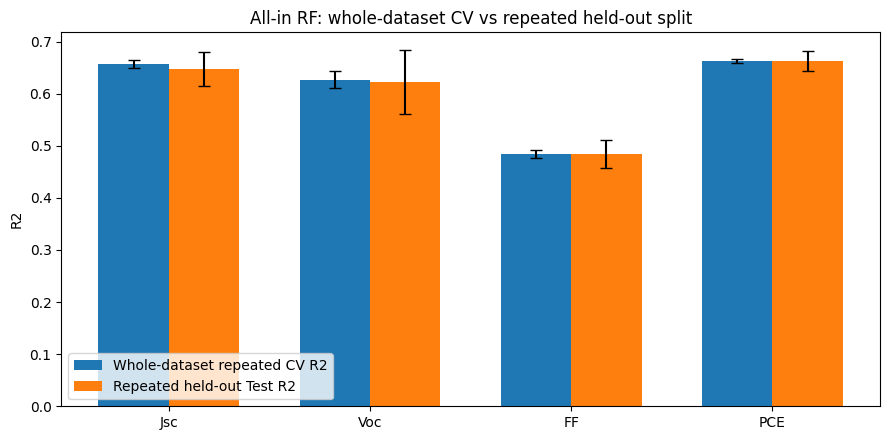

Saved: allin_wholecv_vs_holdout_outputs/bar_wholecv_vs_heldout_r2.png


In [8]:
# ============================================================
# 7a. Bar plot: Whole CV mean vs repeated held-out mean
# ============================================================

plot_df = comparison_summary.copy()
plot_order = ["Jsc", "Voc", "FF", "PCE"]
plot_df["target_short"] = pd.Categorical(plot_df["target_short"], categories=plot_order, ordered=True)
plot_df = plot_df.sort_values("target_short")

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 4.5))
plt.bar(
    x - width/2,
    plot_df["Whole_CV_R2_mean"],
    width,
    yerr=plot_df["Whole_CV_R2_std_across_runs"].fillna(0),
    capsize=4,
    label="Whole-dataset repeated CV R2",
)
plt.bar(
    x + width/2,
    plot_df["Heldout_Test_R2_mean"],
    width,
    yerr=plot_df["Heldout_Test_R2_std"].fillna(0),
    capsize=4,
    label="Repeated held-out Test R2",
)
plt.xticks(x, plot_df["target_short"].astype(str))
plt.ylabel("R2")
plt.title("All-in RF: whole-dataset CV vs repeated held-out split")
plt.legend()
plt.tight_layout()
out_path = OUTPUT_DIR / "bar_wholecv_vs_heldout_r2.png"
plt.savefig(out_path, dpi=200)
plt.show()
print("Saved:", out_path)


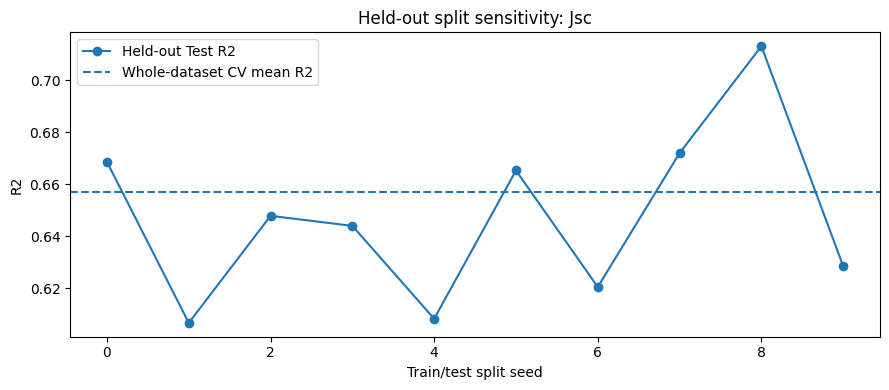

Saved: allin_wholecv_vs_holdout_outputs/line_heldout_r2_vs_wholecv_ref_Jsc.png


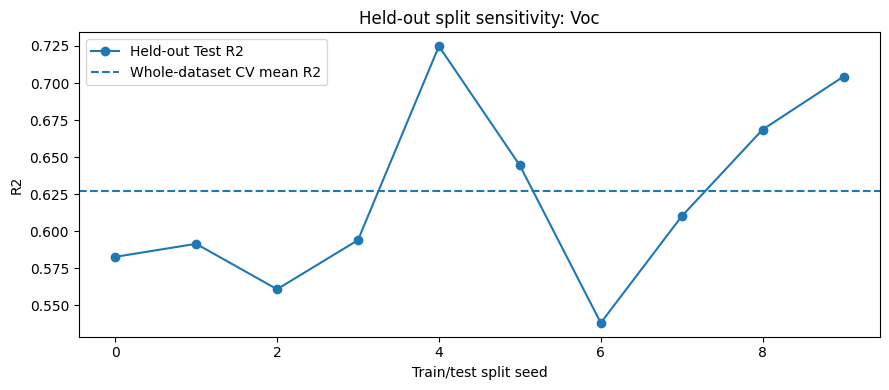

Saved: allin_wholecv_vs_holdout_outputs/line_heldout_r2_vs_wholecv_ref_Voc.png


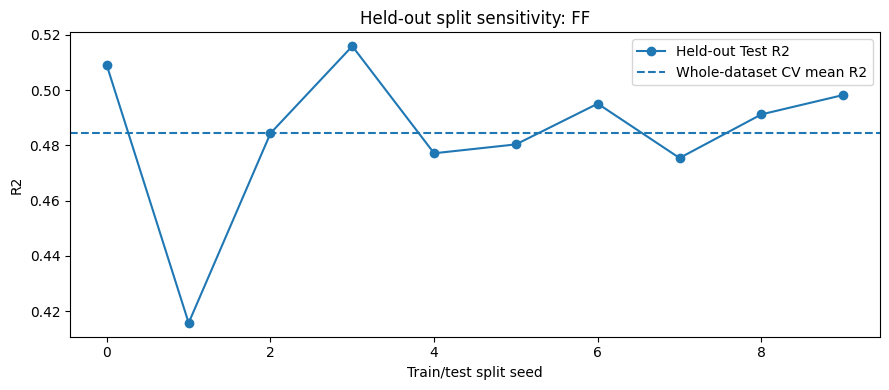

Saved: allin_wholecv_vs_holdout_outputs/line_heldout_r2_vs_wholecv_ref_FF.png


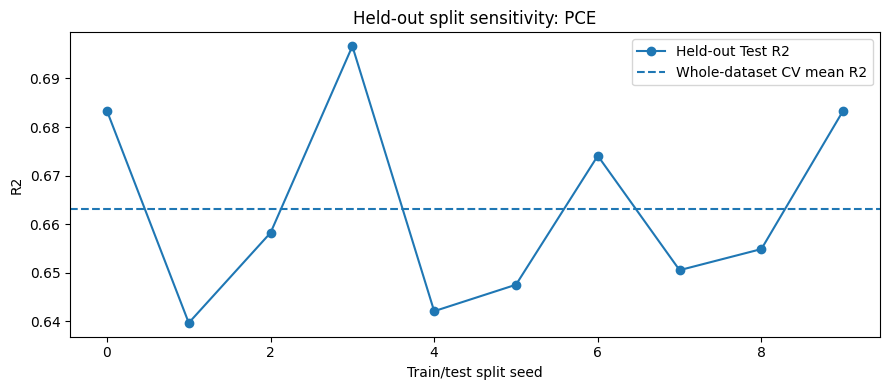

Saved: allin_wholecv_vs_holdout_outputs/line_heldout_r2_vs_wholecv_ref_PCE.png


In [9]:
# ============================================================
# 7b. Line plot: held-out Test R2 across split seeds
# ============================================================

for target_short in plot_order:
    d = holdout_df[holdout_df["target_short"] == target_short].sort_values("split_seed")
    if d.empty:
        continue

    cv_ref = comparison_summary.loc[comparison_summary["target_short"] == target_short, "Whole_CV_R2_mean"]
    cv_ref = cv_ref.iloc[0] if len(cv_ref) else np.nan

    plt.figure(figsize=(9, 4))
    plt.plot(d["split_seed"], d["Test_R2"], marker="o", label="Held-out Test R2")
    if not np.isnan(cv_ref):
        plt.axhline(cv_ref, linestyle="--", label="Whole-dataset CV mean R2")
    plt.xlabel("Train/test split seed")
    plt.ylabel("R2")
    plt.title(f"Held-out split sensitivity: {target_short}")
    plt.legend()
    plt.tight_layout()
    out_path = OUTPUT_DIR / f"line_heldout_r2_vs_wholecv_ref_{target_short}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)


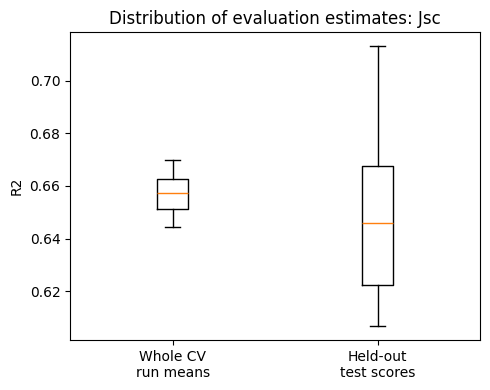

Saved: allin_wholecv_vs_holdout_outputs/box_wholecv_vs_heldout_r2_Jsc.png


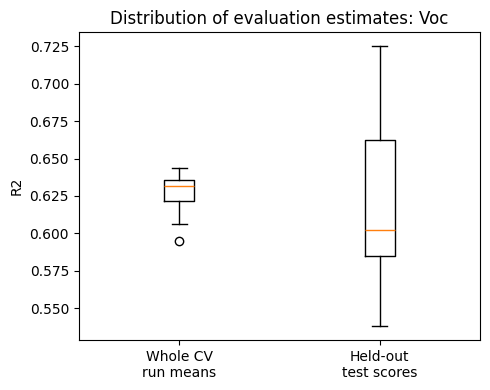

Saved: allin_wholecv_vs_holdout_outputs/box_wholecv_vs_heldout_r2_Voc.png


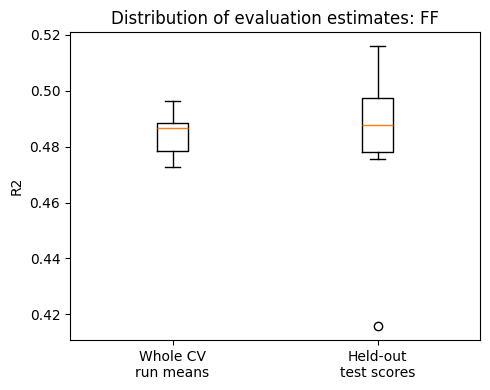

Saved: allin_wholecv_vs_holdout_outputs/box_wholecv_vs_heldout_r2_FF.png


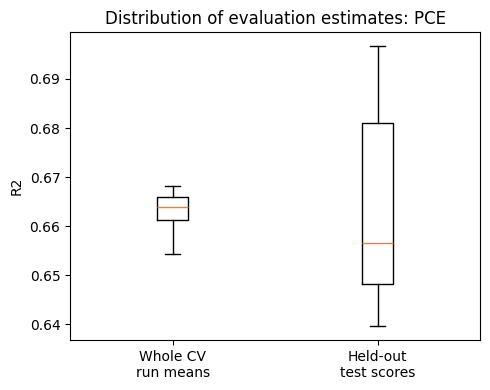

Saved: allin_wholecv_vs_holdout_outputs/box_wholecv_vs_heldout_r2_PCE.png


In [10]:
# ============================================================
# 7c. Boxplot: whole-CV run means vs held-out test scores
# ============================================================

for target_short in plot_order:
    cv_values = whole_cv_df.loc[whole_cv_df["target_short"] == target_short, "CV_R2_mean"].dropna().values
    test_values = holdout_df.loc[holdout_df["target_short"] == target_short, "Test_R2"].dropna().values

    if len(cv_values) == 0 or len(test_values) == 0:
        continue

    plt.figure(figsize=(5, 4))
    plt.boxplot([cv_values, test_values], labels=["Whole CV\nrun means", "Held-out\ntest scores"])
    plt.ylabel("R2")
    plt.title(f"Distribution of evaluation estimates: {target_short}")
    plt.tight_layout()
    out_path = OUTPUT_DIR / f"box_wholecv_vs_heldout_r2_{target_short}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)


## 8. Interpretation

- Whole-dataset 5-fold CV averages over rotating validation folds and therefore gives relatively stable mean estimates.
- A single held-out score depends on one particular 80/20 partition and varies more strongly across seeds, especially for Jsc and Voc.
- Consequently, a single held-out split is not treated as sufficient evidence for comparing feature sets or model structures.
- All subsequent predictive comparisons use the same 10 paired held-out splits (`0–9`) and report mean ± standard deviation.

This conclusion concerns **random-split evaluation stability**. The later DOI-grouped analysis addresses the distinct and stricter question of **cross-source generalisation**.